### Bayesian Statistics

We already introduced Bayes' rule which is as follows:

$$p(M|D) = \frac{p(D|M) p(M)}{p(D)}$$

Here, D stands for the data that we observe and M is the modle that we use. A way of reading this is to say that the "improved belief" is proprtional to the product of the "initial belief" and the probability that the "initial belief" generated the observed data.

But with Model parameters, $\theta$ and background information $I$, it is written as:

$$
p(M,\theta|D,I)=\frac{p(D|M,\theta,I)\,p(M,\theta|I)}{p(D|I)}
$$

$\theta$ represents the model parameters. 

1. $p(M,\theta |D,i)$ is called the posterior pdf for model M and parameters $\theta$ given data D and background information I. And it asks given my observed data, what do I now know about the parameters?
2. $p(D|M,\theta,I)$ is the likelihood. It asks how plausible would the data be if this model, parameters and background assumptions were true.
3. $p(M, \theta|I)$ is the prior for model M. It is our knowledge before incorporating the particular data.

We can also split the prior into two.

$$
p(M,\theta|I)
=
p(\theta|M,I)\,p(M|I).
$$

- $p(\theta|M,I)$ asks, assuming the model is correct, which parameter values are plausible.
- $p(M|I)$ asks, before seeing the data, how plausible is model M itself?

When we want to estimate parameters, we only need to specify the first one, however for model selection we require the full prior.

> I wanted to just emphasise to myself what model actually means again, it is a belief that data behaves according the a mathematical mechanism, for the bus problem in Izevic where if we arrive at a bus stop, the time we wait is t, then what is the subsequent time between busses if we don't know the schedule. Our model in this case is that the busses arive perfectly regularly every $\tau$ minutes and I arrive at a random time between busses leading to
>
> $$
p(t|\tau,M)
=
\begin{cases}
\dfrac{1}{\tau}, & 0\leq t\leq\tau,\\
0, & \text{otherwise}.
\end{cases}
>$$
> And a parameter is a number within the model that we don't know which in this case is $\tau$
> So to justify, $p(D|M,\theta)$ means ASSUME my model $M$ is correct, and assume the parameters have particular values $\theta$. How plausible would my observed data be?


The denominator ensures the posterior integrates to 1, so it is normalised. This becomes more important when comparing models, but for parameter inference we can just calculate the right side of the following and normalise afterwards.

$$
p(\theta|D)
\propto
p(D|\theta)p(\theta).
$$

> If we wish to measure the mass of saturn for example, it's true mass isn't changing every time we observe it. Frequentists would say $m$ is fixed but unknown, whereas we still use $p(m|D)$. This distribution represents our uncertainty about its fixed value.






#### The Complete Bayesian Analysis:

1. Formulating the data likelihood $p(D|\theta,M,I)$. This is the model for how the data will be generated
2. Choosing the prior, it incorporates all other knowledge, but is not used when calculating the likelihood.
3. Determining the posterior pdf

$$
p(\theta|D,M,I)
\propto
p(D|\theta,M,I)p(\theta|M,I).
$$

4. Then we search for the best model parameters, which maximise $p(\theta| D, M, I)$ yielding a MAP estimate.

Another way to point estimate, we can use the posterior mean, $\bar{\theta}$ which calculates the expected value by integrating over the entire posterior distribution. This gives the average parameter value, while MAP gives the single most probable parameter point.

5. Then we need to find our uncertainties, this uses credible regions. For simple models, we can use exact formulas, whereas for complex models we generate random samples from the posterior this is similar to the frequentist bootstrap method but it is either MCMC or nested sampling that is used.
6. Hypothesis testing is used to make other conclusions about the model or parameter estimates. This uses priors and so can be different from the classical statistics approach.

#### How do we choose the prior?

It comes from previous knowledge, if a previous experiment had a particular posterior, that can be used as your new prior. This is known as an informative prior.

#### What if we don't have prior information?

1. We could use a flat prior,

$$
p(\theta)\propto C.
$$

however, we are stating here that $\theta$ is equally weighted which comes with the following problem:

$$
\int_{-\infty}^{\infty} C\,d\theta=\infty.
$$

We don't get a valid PDF. This is an improper prior. It is mostly fine if the resulting posterior is a generally defined pdf.

2. A flat prior on a parameter does not imply a flat prior on a transformed version of the parameter.

3. We can use a lower and upper limit on $\theta$ for example mass being positive and less than the Earth for example


#### Principle of Max entropy



If we know some information, but not enough to uniquely determine a prior, what distribution should we use?

We choose the one that adds the least extra assumptions (Occams Razor), and the entropy follows:

> A least assumption distribution is one with the most uncertainty, this gives the highest entropy, given the constraints

$$
S=-\sum_i p_i\ln p_i.
$$

For a pdf with N discrete values, where N denotes all possibilites.

>We can also think of entropy as the sum of the surprise of an outcome occuring multiplied by the probability of the surprise, which has the same exact equation and surprise is defined as: $\log(\frac{1}{p(x)})$
>
> As we may think aready, if an event is very likely, then the surprise is near 0 and vice versa
> If we take the average of the surprise, we measure the total lack of information within the system

The entropy is high when probability spreads out and low when it concentrates. 


We can look at a particular example with six sided die. 

Given six probabilities, $p_i$, the expected mean is 

$$
\sum_{i=1}^6 i\,p_i=\mu.
$$

And we know that the probabilites must add up to 1:

$$
\sum_{i=1}^6p_i=1.
$$

These form our constraints for the unknown values, $p_i$. But these values can be found using maximum entropy and lagrangian multipliers:

$$
Q
=
S
+
\lambda_0
\left(
1-\sum_i p_i
\right)
+
\lambda_1
\left(
\mu-\sum_i ip_i
\right).
$$

Where,

$$S = - \sum^6_{i=1} p_i \ln \left( \frac{p_i}{m_i} \right)$$


By differentiating with respect to $p_i$ we get the conditions and hence solutions that:

$$p_i = m_i \exp(-1 -\lambda_0) \exp(i \lambda_1)$$

> So using this equation, lets say we have no reason to prefer heads over tails, then $m_0,m_1 =1$. We have tails, $i = 1$, and heads, $i = 0$:
>$$p_0 = A \cdot \exp(0 \cdot \lambda_1) = A \cdot 1 = A \qquad \qquad p_1 = A \cdot \exp(1 \cdot \lambda_1) = A \cdot e^{\lambda_1}$$
> Then we use the rules that we set prior: $p_0 + p_1 = 1$ and $0(p_0) + 1(p_1) = \mu$
> So we get
> $$p_1 = \mu \qquad \qquad p_0 = 1 - \mu $$
> What does $\lambda$ mean? We can think of it as a pressure, that moves our probability away from 50/50.
> If the mean is 0.5, then $e^{\lambda_1} = 1$, which means $\lambda_1 = 0$
> We can find this by:
> $$\lambda_1 = \ln\left(\frac{\mu}{1-\mu}\right)$$

If we extend this to infinite possible discrete events, the resulting maximum entropy distribution depends on the measured $m_i$. With a constant $m_i$, fixing only the mean gives a geometric distribution. Choosing $m_i\propto1/i!$ gives the Poisson distribution.

##### continuous case

For the same corresponding continuous case, where we know the expectation value for $\theta$, and it's positive, we get:

$$
p(\theta|\mu)
=
\frac1\mu e^{-\theta/\mu}.
$$

And if the variable spans the entire real line, and we know its mean and variance, then the maximum entropy distribution is gaussian.

##### Kullback - Liebler divergence

$$
D_{\rm KL}(p||m)
=
\sum_i p_i\ln\left(\frac{p_i}{m_i}\right).
$$

This distribution asks the question: "How much information is required to move from distributon $m$ to distribution $p$?

Let's say the prior and posterior are almost identical, then the data didn't do a great job and taught us very little. However, if the posterior shifts away from the prior by a lot, we know the data told us a lot.

Hence this KL distribution can quantify the information gain from prior to posterior.

#### Conjugate priors

This is where the prior times the likelihood gives a posterior with the same family of distribution as the prior.

An example of this is that a Gaussian prior, and a Gaussian likelihood gives a Gaussian posterior.

Lets say our prior is:

$$
\theta\sim\mathcal N(\mu_p,\sigma_p).
$$

$\theta$ is the unknown parameter we are trying to estimate. We believe it is around $\mu_p$ with uncertainty $\sigma_p$

> Say we did a previous experiment, which told us that $\theta = 10 \pm 2$, then we can use $\mu_p = 10, \sigma_p = 2$. Then we collect new data, $D\sim\mathcal N(\bar{x},s)$, and the experiment says that $\bar{x} = 12, s =1$, we get a disagreement. The posterior should lie between 10 and 12, this is what the following equation calculates.

Say the posterior follows

$$
D\sim\mathcal N(\bar{x},s).
$$

$$
\mu^0
=
\frac{
\mu_p/\sigma_p^2+\bar{x}/s^2
}{
1/\sigma_p^2+1/s^2
}
$$

To understand this lets define a term called precision:

$$

\text{precision}
=
\frac{1}{\text{variance}}
=
\frac{1}{\sigma^2}

$$

High precision means small uncertainty, and with this fact we can rewrite the above equation to be:

$$
\mu^0
=
\frac{
(\text{prior mean})(\text{prior precision})
+
(\text{data mean})(\text{data precision})
}{
\text{prior precision}
+
\text{data precision}
}
$$

So the equation is simply taking the weighted average of $\mu_p$ and $\bar{x}$.

1. If $s<\sigma_p$ then the posterior distribution lies closer to $\bar{x}$ than to $\mu_p$
2. If $\sigma \ll s$ then $\frac1{\sigma_p^2}\gg\frac1{s^2}$ so the prior has a larger waiting
3. An informative prior is one where $\mu^0\approx\mu_p$ as we need strong new information to move away from it

##### What about the Posteriors uncertainty?

$$
\sigma^0
=
\left(
\frac1{\sigma_p^2}
+
\frac1{s^2}
\right)^{-1/2}
$$

We can once again think about this in terms of precision:

$$

\frac1{(\sigma^0)^2}
=
\frac1{\sigma_p^2}
+
\frac1{s^2}

$$

##### New example

Say we are tossing a coin with an unknown probability of getting heads, if the heads probability is b then:

$$
0\leq b\leq1
$$

We need a prior distribution over all the values of b. However, a Gaussian would extend below 0 and above 1 so we use a beta distribution.

And so we get the following:

$$

\text{Binomial likelihood}
+
\text{Beta prior}
\rightarrow
\text{Beta posterior}
$$

So just talking a little bit about the beta distribution. The shape is determined by $\alpha$ and $\beta$.

Where the prior would be written as:

$$
b\sim\operatorname{Beta}(\alpha_p,\beta_p)
$$

If we do a binomial test with k successes, then the likelihood multiplied by the prior would become:

$$
p(b|D)
\propto
b^k(1-b)^{N-k}
b^{\alpha_p-1}(1-b)^{\beta_p-1}
$$

Where the posterior parameters are just:

$$
\alpha^0=\alpha_p+k \qquad \qquad \qquad \beta^0=\beta_p+N-k

$$

### Hierarchal and Empirical Bayes

For empirical bayes we can use the data to estimate the prior. 


##### Hierarchal:

Say we had 100 different supernova populations, each with their own true quantity, e.g intrinsic luminosity.

This would then follow (if there was noisy data associated):

$$
p(\theta_i|D_i)
\propto
p(D_i|\theta_i)p(\theta_i).
$$

But this ignores that the objects can belong to the same population, so if we think the individual parameters come from a Gaussian distribution:

$$
\theta_i\sim\mathcal N(\mu,\sigma).
$$

This would just mean that the true value tends around a population mean and scatter. But it creates two unknowns, $\sigma$ and $\mu$ which are called hyperparameters because they are parameters of another parameter, $\theta$.

However, these hyperparameters are uncertain too so we assign distributions to these such as:

$$
\mu\sim p(\mu) \qquad \qquad \sigma\sim p(\sigma)
$$

These are known as Hyperpriors.


So to distinguish between Hierarchal and Empirical Bayes:
>In empirical Bayes, the hyperparameters are estimated from the data and then treated as fixed. In hierarchical Bayes, we instead treat the hyperparameters as uncertain and assign them hyperpriors.


### Credible Intervals

We are talking about step 5 on the Complete Bayesian analysis.

Since we have the posterior, we wish to describe its uncertainty, for a central credible interval, we choose a and b such that:

> A credible interval is an interval containing a chosen amount of posterior probability

$$
\int_{-\infty}^{a}p(\theta|D)\,d\theta
=
\frac{\alpha}{2},
$$

and

$$
\int_b^\infty p(\theta|D)\,d\theta
=
\frac{\alpha}{2}.
$$

Then we get:

$$
P(a<\theta<b|D)=1-\alpha.
$$

This means that we believe that the true value of $\theta$ has a 95% chance of being between a and b.

If we want a 95% interval, then $\alpha$ = 5%. 

### Marginalization of parameters

When analysing data, we need to model complex effects such as position and width of a spectral line. The background noise is a variable within the model that we don't care about (in this instance) and we call them nuisance parameters. Since we don't care about it, we can integrate the full joint probability distribution over all values of the nuisance parameter. Hence, the resulting pdf depends only on the parameters we want.

$$
p(\mu|D)=\int p(\mu,B|D)\,dB.
$$

Here we are integrating over all background data, leaving us with the central wavelength, $\mu$.

### Model selection

Which models do we prefer?

To see which of two models is better supported by data, we compare their posterior proabbilities via the odds ratio:

$$
O_{21}
=
\frac{p(M_2|D,I)}
{p(M_1|D,I)}.
$$

After analysing some data you may simply find:

$$
p(M_2|D)=0.8 \qquad \qquad p(M_1|D)=0.2 \qquad \qquad O_{21}=\frac{0.8}{0.2}=4
$$

This means that $M_2$ is 4 times more probable as $M_1$ under the model set and priors.

To calculate these we use:

$$
p(M|D,I)=\frac{p(D|M,I)p(M|I)}{p(D|I)}
$$

This is just ordinary Bayes' equation, just with finding the model as the unknown.

The hard part is the denominator. And we define it as the evidence:

$$
E(M)
\equiv
p(D|M,I)
=
\int
p(D|M,\theta,I)
p(\theta|M,I)
\,d\theta
$$

Here we are caclulating the prior-weighted average likelihood over all possible parameters.

We used marginalisation before to leave us only with the model:

$$
p(D|M)
=
\int
p(D,\theta|M)\,d\theta
$$

So now that we know about evidence, using the equation before we can form:

$$
O_{21}
=
\frac{
E(M_2)p(M_2|I)
}{
E(M_1)p(M_1|I)
}
$$

Where we can also define:

$$
B_{21}
=
\frac{E(M_2)}{E(M_1)}.
$$

As the Bayes factor, and it asks how much more strongly does the data support model 2 than model 1 before applying the priors.

$$
B_{21}
=
\frac{
\int p(D|M_2,\theta_2,I)p(\theta_2|M_2,I)\,d\theta_2
}{
\int p(D|M_1,\theta_1,I)p(\theta_1|M_1,I)\,d\theta_1
}.
$$

### Bayesian Hypothesis testing

SO MUCH THEORY SO FAR ITS INTENSE

In Bayesian Hypothesis testing, we ask which proposed model explains the data better.

For example, lets say we are flipping a coin and want to know the probability of getting heads. And we are saying we flipped the coin $N = 20$ times and obtained $k = 16$ heads

$$
M_1:\;b=0.5.
$$
$$
M_2:\;0<b<1.
$$

Here we are saying our alternative hypothesis that the coin has an unknown heads probability

We directly compare $p(M_1|D)$ and $p(M_2|D)$

Which is the same as:

$$B_{21} = \frac{p(D|M_2)}{p(D|M_1)}$$


## LECTURE 8 (finally)

First lets generate a homoscedastic sample from a Gaussian and see what happens with L, we will also compute probabilities for each point, multiplying them to form the likelihood:

In [17]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
np.random.seed(42)

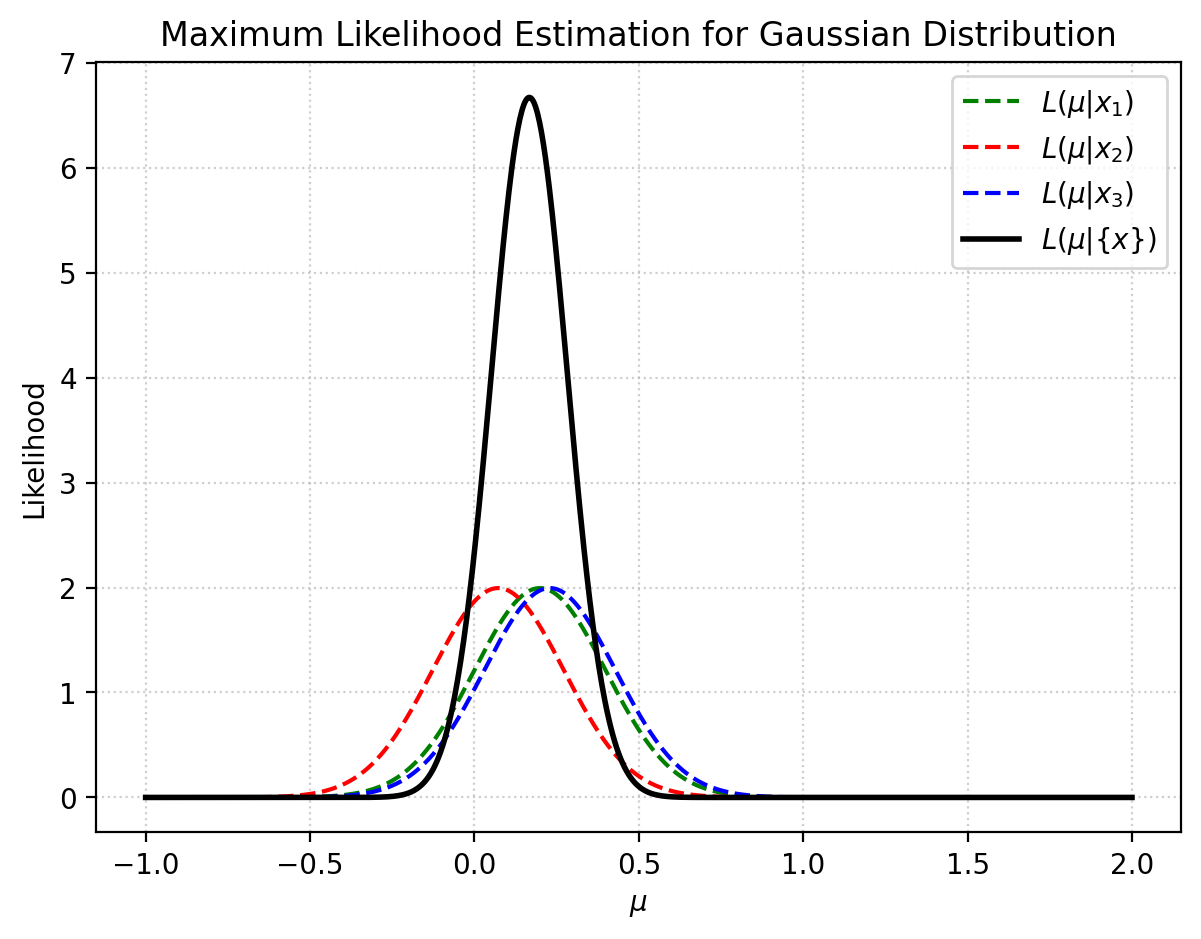

In [18]:
# Define true parameters and generate sample data
sampleSize = 3
mu = 0.1
sigma = 0.2 
sample = norm(mu, sigma).rvs(sampleSize) 

# Create parameter grid for evaluating the likelihood
Grid = np.linspace(-1, 2, 1000) 

# Calculate individual likelihoods for each observation
L1 = norm(sample[0], sigma).pdf(Grid) 
L2 = norm(sample[1], sigma).pdf(Grid) 
L3 = norm(sample[2], sigma).pdf(Grid) 

# Combine individual likelihoods to find the joint likelihood
L = L1 * L2 * L3 

# Plot the individual and joint likelihood curves
fig, ax = plt.subplots(figsize=(7, 5)) 
plt.plot(Grid, L1, ls='--', c='green', label=r'$L(\mu|x_1)$') 
plt.plot(Grid, L2, ls='--', c='red', label=r'$L(\mu|x_2)$') 
plt.plot(Grid, L3, ls='--', c='blue', label=r'$L(\mu|x_3)$') 
plt.plot(Grid, L, ls='-', c='black', lw=2, label=r'$L(\mu|\{x\})$') 

# Configure chart details
plt.xlabel(r'$\mu$') 
plt.ylabel(r'Likelihood') 
plt.title('Maximum Likelihood Estimation for Gaussian Distribution') 
plt.legend() 
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

If this is for the mass of a galaxy, it couldn't possibly be negative so we apply this prior information to get:

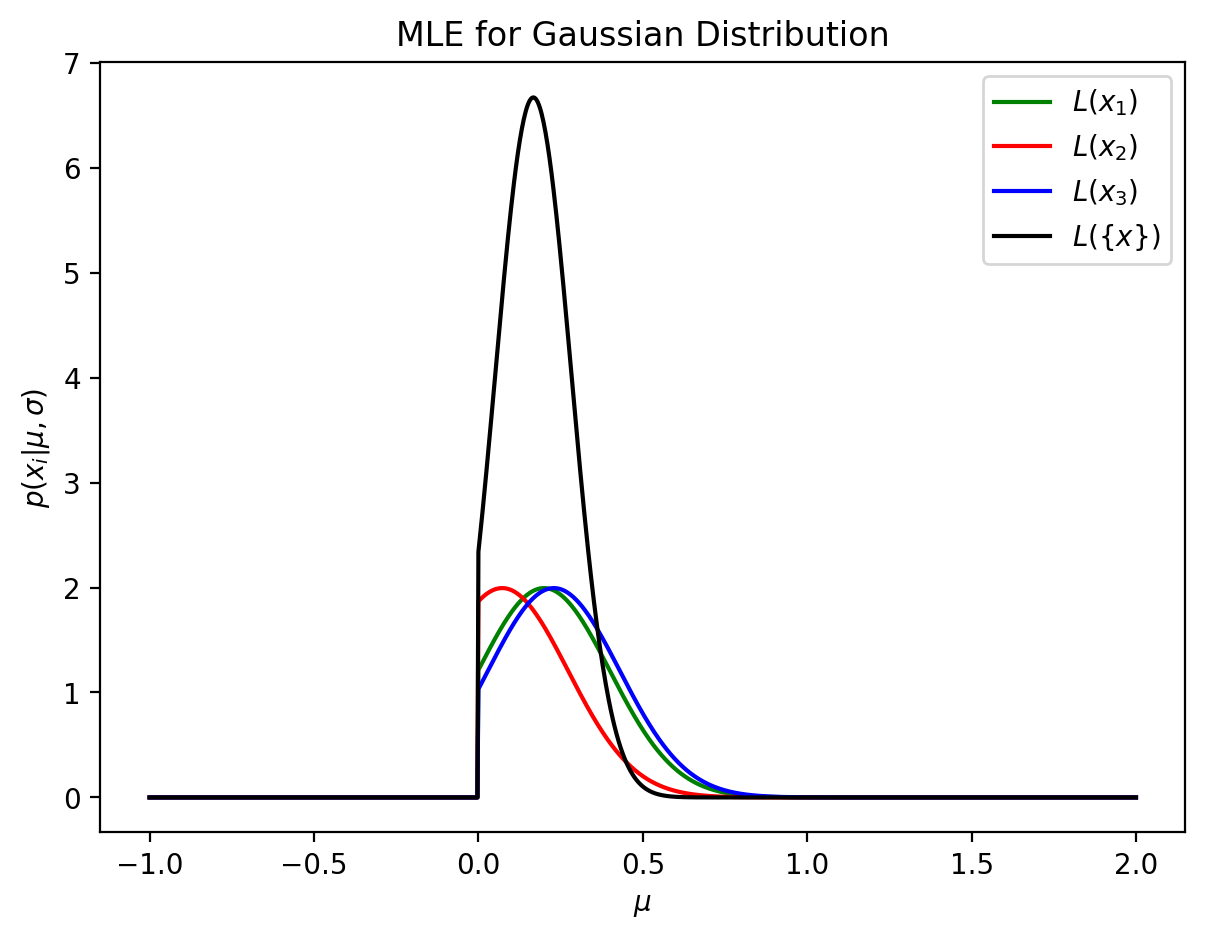

In [19]:
muMin = 0
L1[Grid < muMin] = 0
L2[Grid < muMin] = 0
L3[Grid < muMin] = 0
L = L1 * L2 * L3

# plot
fig, ax = plt.subplots(figsize=(7, 5))
plt.plot(Grid, L1, ls='-', c='green', label=r'$L(x_1)$')
plt.plot(Grid, L2, ls='-', c='red', label=r'$L(x_2)$')
plt.plot(Grid, L3, ls='-', c='blue', label=r'$L(x_3)$')
plt.plot(Grid, L, ls='-', c='black', label=r'$L(\{x\})$')

#plt.xlim(0.2, 1.8)
#plt.ylim(0, 8.0)
plt.xlabel('$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.title('MLE for Gaussian Distribution')
plt.legend()
plt.show() 

Say we wish to analyse a coin toss, the probability of getting $h$ heads, in $n$ flips is given by the binomial prob distribution,
> $P(h|\theta) \propto \theta^h (1-\theta)^{(n-h)}$

Where $\theta$ is the probability of a head.

Lets say we wish to calculate and plot the Bayesian posterior of the probability of drawing a head when we see 5,50 and 500 coin flips:

What we need is to 
1. formulate the likelihood, $p(D\,|\,M,\theta,I)$
2. choose a prior
3. plot the posterior, $p(M,\theta \,|\,D,I)$

In [20]:
data = np.array([
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1])

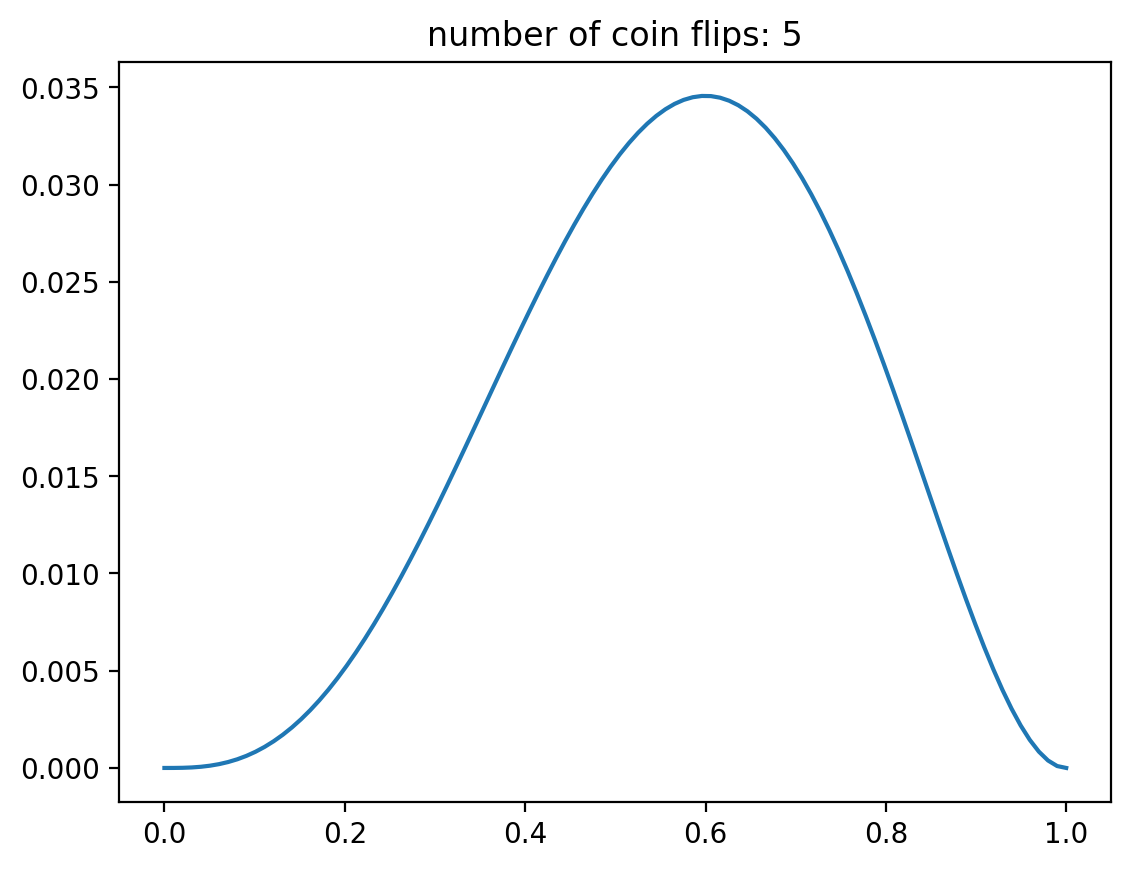

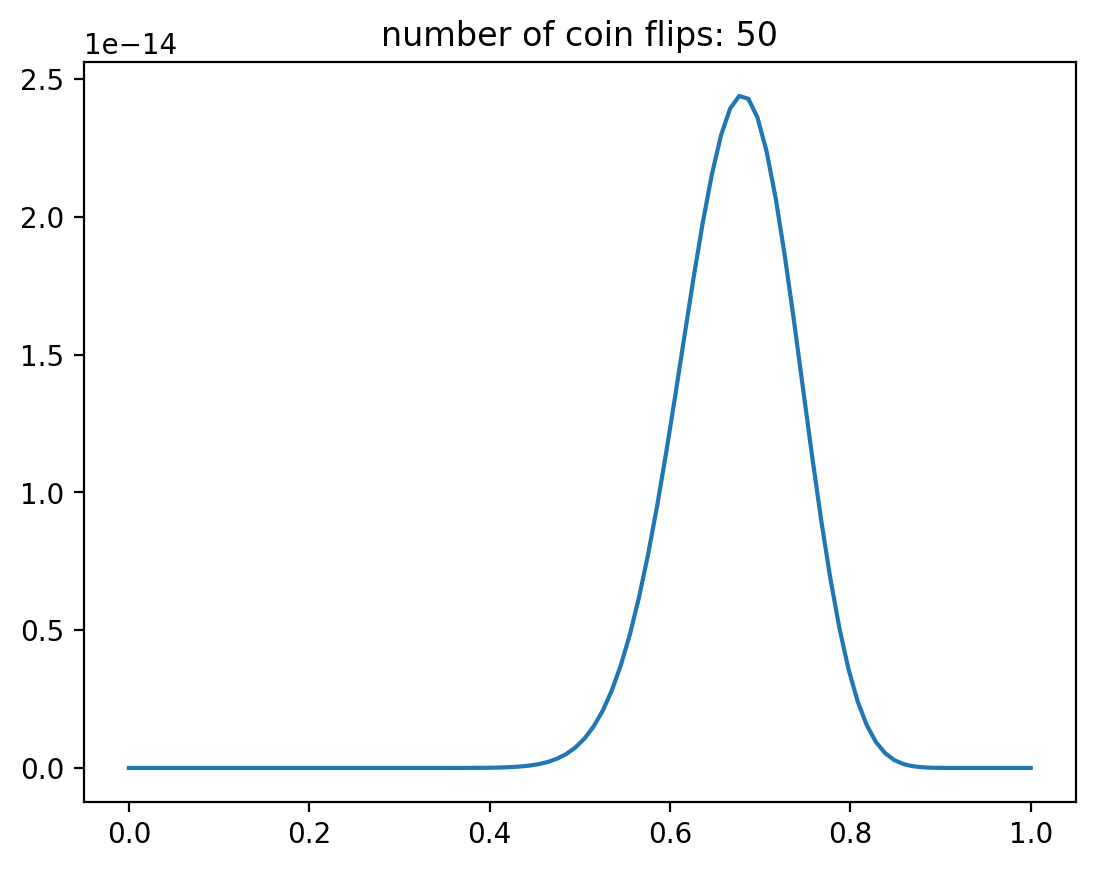

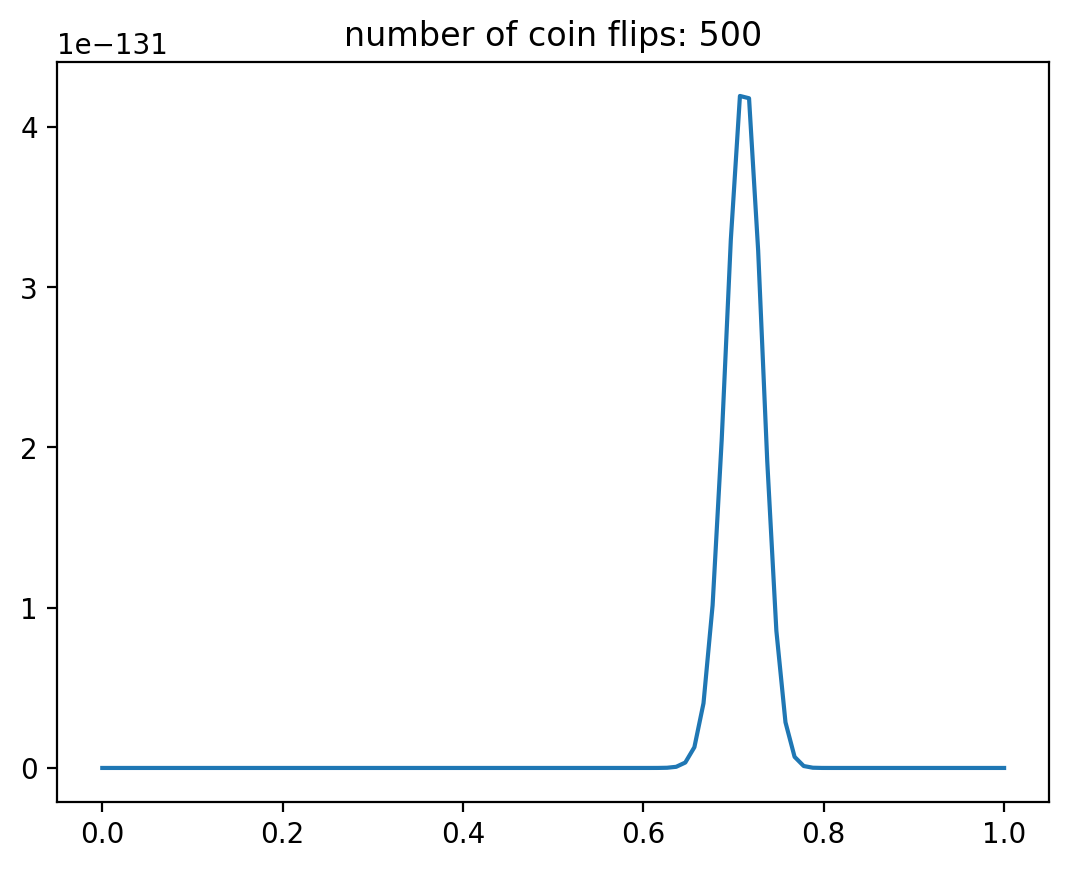

In [21]:
def p_nheads(n, h, theta):
    return (theta**h) * ((1-theta)**(n-h))

# likelihood
def L(data, ntrials, theta):
    nheads = data[:ntrials].sum()
    return p_nheads(ntrials, nheads, theta)

# prior. Just uniform?
def prior(theta):
    return 1

probs = []
# define the number of trials
n_trials = [5, 50, 500]
theta = np.linspace(0, 1, 100)
for nt in n_trials:
    prob = L(data, nt, theta) * prior(theta)
    # posterior plot
    plt.plot(theta, prob, 
            label=r'ntrial = '+str(nt))
    # likelihood plot
    #plt.plot(theta, L(data, nt, theta))
    plt.title("number of coin flips: "+str(nt))  
    plt.show()

We can see that the posterior becomes narrower when we have more data, we didn't normalise the posterior as we are just looking at the relative shape, using:

$$p(\theta|D)
\propto
L(\theta)p(\theta)$$

If we already know the gambler, we have seen the experiment before and saw that the coin tends to land on tails. We can use an informative prior.

Here we can see what happens when we use a $\beta$ function instead for the prior.

$$P(\alpha, \beta, \theta) = \theta^{\alpha-1} (1-\theta)^{(\beta-1)}$$

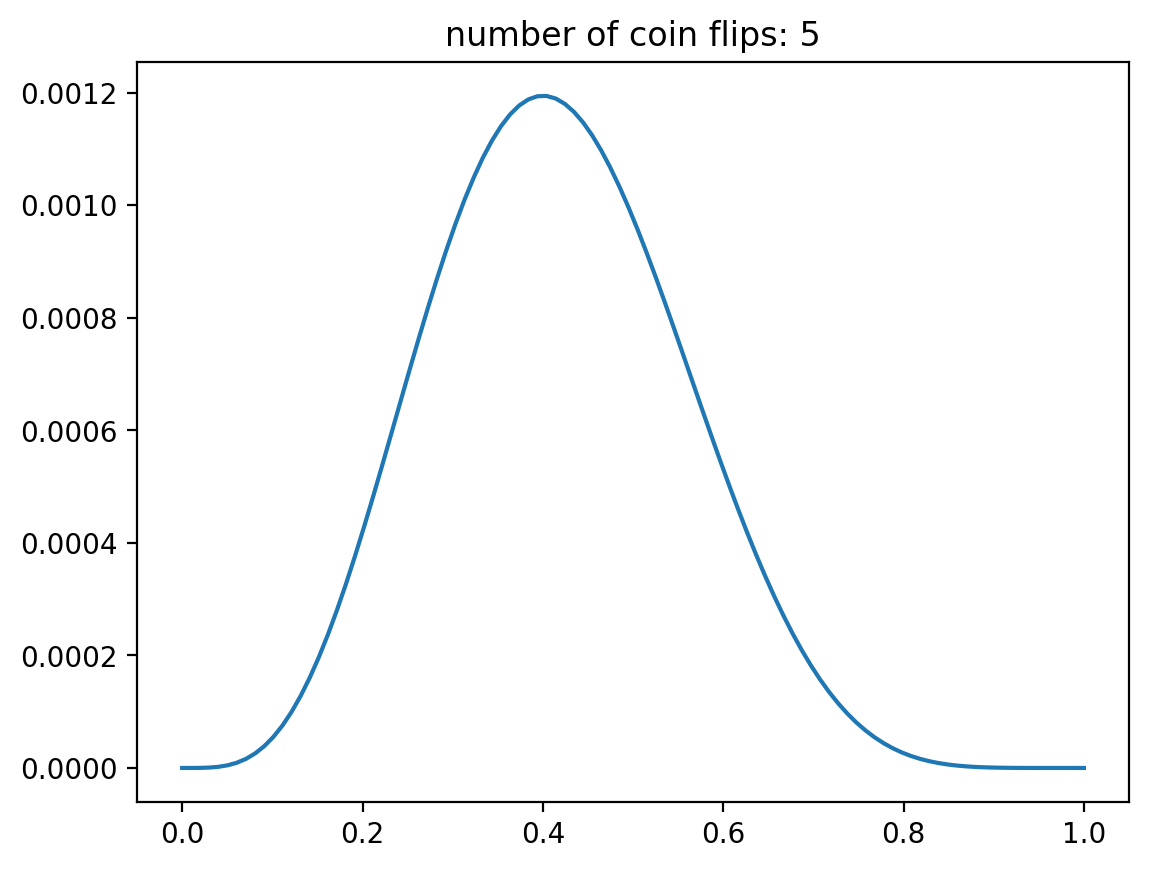

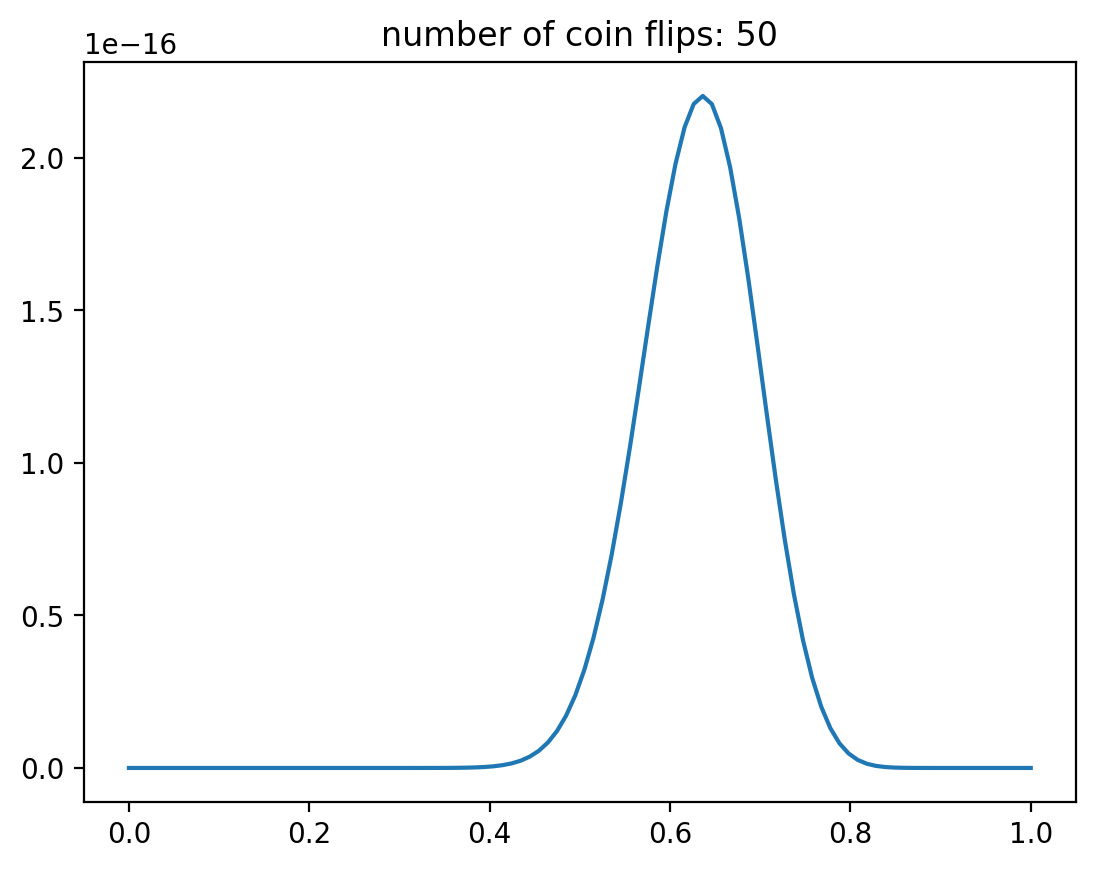

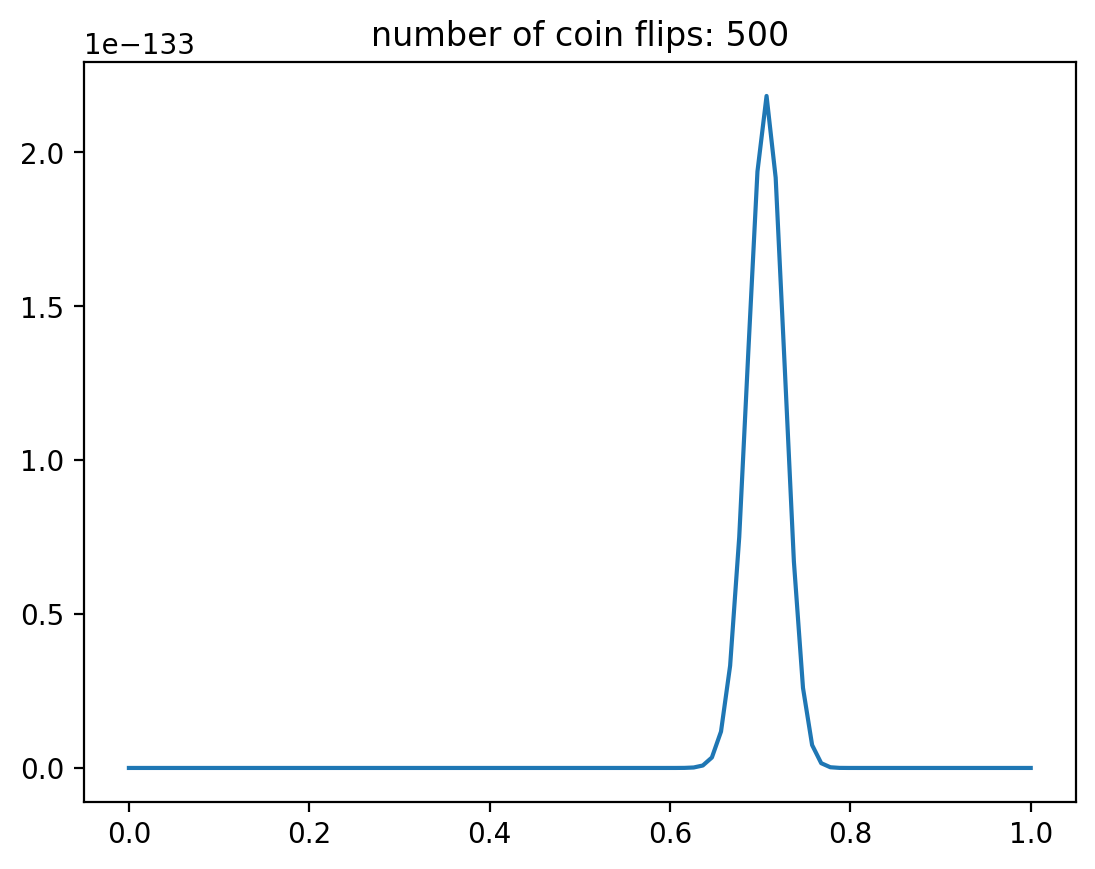

In [22]:
def p_nheads(n, h, theta):
    return (theta**h) * ((1-theta)**(n-h))

# likelihood
def L(data, ntrials, theta):
    nheads = data[:ntrials].sum()
    return p_nheads(ntrials, nheads, theta)

def prior(theta):
    alpha=2
    beta=5
    return  (theta**(alpha-1)) * ((1-theta)**(beta-1))

probs = []
# define the number of trials
n_trials = [5, 50, 500]
theta = np.linspace(0, 1, 100)
for nt in n_trials:
    prob = L(data, nt, theta) * prior(theta)
    # posterior plot
    plt.plot(theta, prob, 
            label=r'ntrial = '+str(nt))
    # likelihood plot
    #plt.plot(theta, L(data, nt, theta))
    plt.title("number of coin flips: "+str(nt))  
    plt.show()

We can see that as the amount of data increases, inference is more related to the data rather than the prior, as the final image looks pretty similar whereas the first images look different.

### References


[Bayes' Theorem Clearly Explained - Statquest](https://www.youtube.com/watch?v=9wCnvr7Xw4E)

[3Blue1Brown Bayes Theorem](https://www.youtube.com/watch?v=HZGCoVF3YvM)

[Entropy Statquest](https://www.youtube.com/watch?v=YtebGVx-Fxw)

[Used on a little bit for Hierarchal, like slide 37, from Notre Dame univeristy](https://www.dropbox.com/scl/fi/9uwx406qpuwud0ppwyeni/Priors-HierarchicalBayesianModels.pdf?rlkey=1vxi167l83vbuq4u58917n2js&e=1&dl=0)

[Lecture used for help, L08](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/04364b4ef23197ae77027fed5395b3a706703dec/lectures/L08_bayesian.ipynb)


#### Extra added on day 12 for intuition:

[Intuition of Bayesian inference - Ben Lambert](https://www.youtube.com/watch?v=yvWlpwnT1nw)